In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
import umap

In [22]:
# --- IRIS DATASET ---
iris = load_iris()

data = iris.data

labels = iris.target_names[iris.target]

df = pd.DataFrame(
    data,
    columns=['F1', 'F2', 'F3', 'F4']
)

X_scaled = df.values

In [26]:
pca_res = PCA(n_components=2).fit_transform(X_scaled)

In [27]:
# t-SNE
tsne_res = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
).fit_transform(X_scaled)

In [28]:
# UMAP
umap_res = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    random_state=42
).fit_transform(X_scaled)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


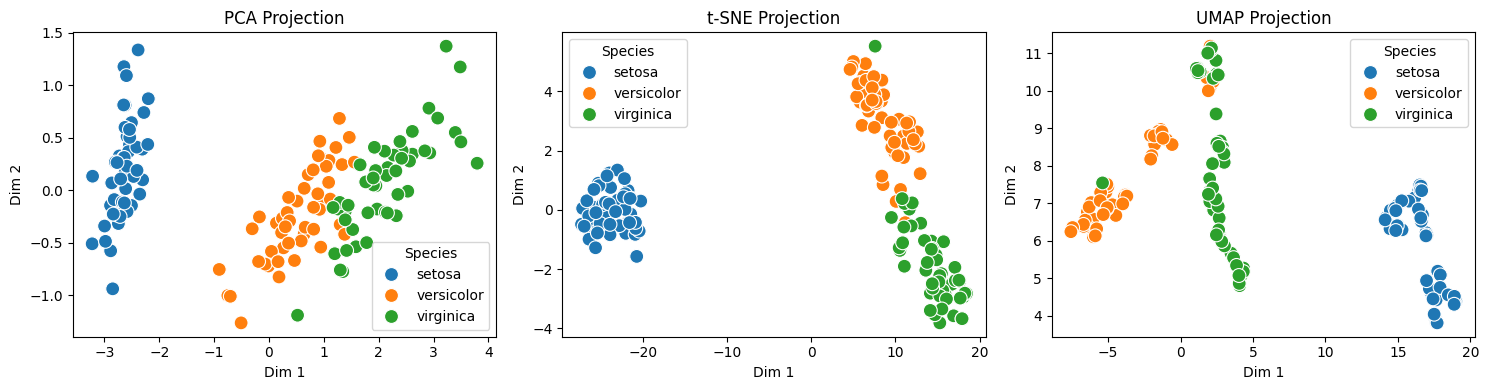

In [29]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results = [
    ('PCA', pca_res),
    ('t-SNE', tsne_res),
    ('UMAP', umap_res)
]

for ax, (title, res_data) in zip(axes, results):

    plot_df = pd.DataFrame(
        res_data,
        columns=['Dim 1', 'Dim 2']
    )

    plot_df['Species'] = labels

    sns.scatterplot(
        data=plot_df,
        x='Dim 1',
        y='Dim 2',
        hue='Species',
        ax=ax,
        s=100
    )

    ax.set_title(f"{title} Projection")

plt.tight_layout()
plt.show()